### Ridewise --- Exploratory Data Analysis (EDA)

#### Setup & Inports

In [32]:
# import libraries

import os,  warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# configurations (render plots directly in the notebook)
warnings.filterwarnings("ignore")
%matplotlib inline       

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"figure.dpi":110, "axes.spines.top":False, "axes.spines.right":False})

#### Step 2a - Loading the data

In [33]:
# load the dataset

riders = pd.read_csv("C:/Users/Uche/OneDrive/Documents/GitHub/Ridewise_London_Uche/data/raw/riders.csv", parse_dates=["signup_date"])
trips = pd.read_csv("C:/Users/Uche/OneDrive/Documents/GitHub/Ridewise_London_Uche/data/raw/trips.csv")
drivers = pd.read_csv("C:/Users/Uche/OneDrive/Documents/GitHub/Ridewise_London_Uche/data/raw/drivers.csv", parse_dates=["signup_date"])
sessions = pd.read_csv("C:/Users/Uche/OneDrive/Documents/GitHub/Ridewise_London_Uche/data/raw/sessions.csv")
promotions = pd.read_csv("C:/Users/Uche/OneDrive/Documents/GitHub/Ridewise_London_Uche/data/raw/promotions.csv")

In [34]:
# Quick data overview

for name, df, in [("riders", riders), ("trips", trips), ("drivers", drivers), ("sessions", sessions), ("promotions", promotions)]:
    print( f" {name:<12} {df.shape[0]:>7} rows {df.shape[1]:>2} cols")

 riders         10000 rows  8 cols
 trips         200000 rows 16 cols
 drivers         5000 rows  7 cols
 sessions       50000 rows  8 cols
 promotions        20 rows 11 cols


#### Step 2b - Data Inpection

In [35]:
# inpections of the riders dataset
print(riders.dtypes)
print(riders.isnull().sum())
riders.head()

user_id                     object
signup_date         datetime64[ns]
loyalty_status              object
age                        float64
city                        object
avg_rating_given           float64
churn_prob                 float64
referred_by                 object
dtype: object
user_id                0
signup_date            0
loyalty_status         0
age                    0
city                   0
avg_rating_given       0
churn_prob             0
referred_by         6947
dtype: int64


,user_id,signup_date,loyalty_status,age,city,avg_rating_given,churn_prob,referred_by
0,R00000,2025-01-24,Bronze,34.729629,Nairobi,5.0,0.142431,R00001
1,R00001,2024-09-09,Bronze,34.571020,Nairobi,4.7,0.674161,NaN
2,R00002,2024-09-07,Bronze,47.133960,Lagos,4.2,0.510379,NaN
3,R00003,2025-03-17,Bronze,41.658628,Nairobi,4.9,0.244779,NaN
4,R00004,2024-08-20,Silver,40.681709,Lagos,3.9,0.269960,R00002


#### Step 3 - Visualisation of the Riders (Data distribution)

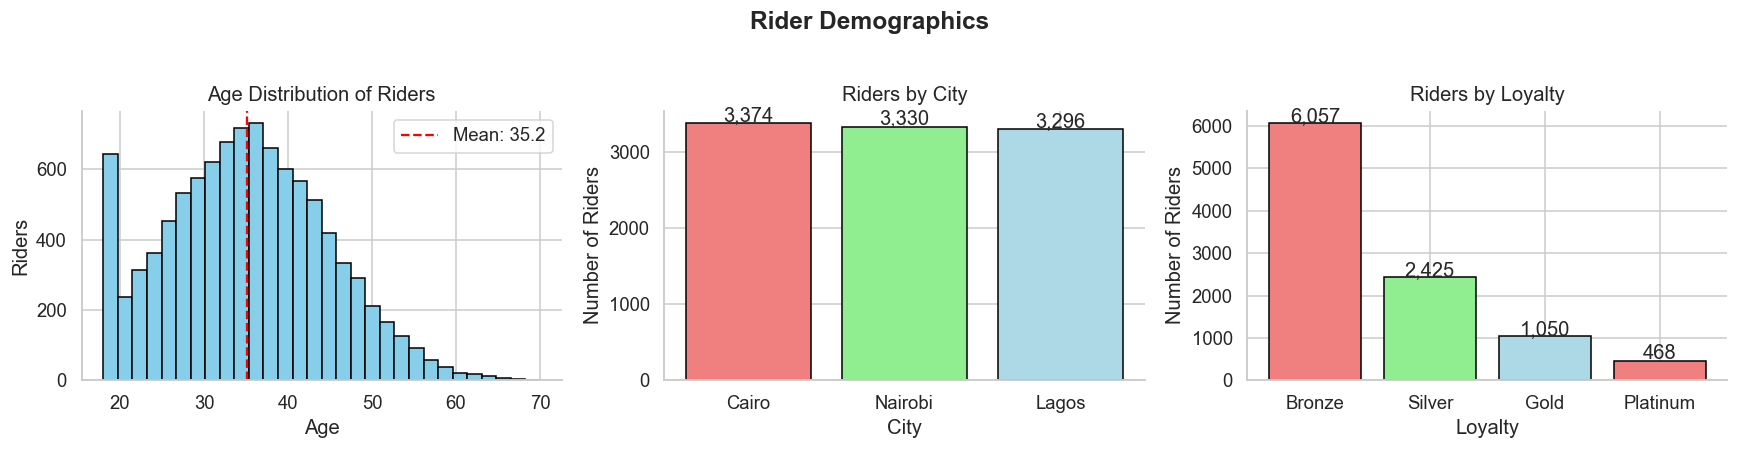

In [36]:
# Age distribution of riders (configure the figure)

# step 3a define the figure size and style
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# step 3b plot the age distribution (18-30, 30-50, 50+)
axes[0].hist(riders["age"].dropna(), bins=30, color="skyblue", edgecolor="black")
axes[0].axvline(
    riders["age"].mean(),color="red", linestyle="dashed",
    label=f"Mean: {riders['age'].mean():.1f}"
)

# step3c configure the plot
axes[0].set_title("Age Distribution of Riders")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Riders")
axes[0].legend()

#################### PART 2 ##################################
# step 3d City Distribution
city_counts = riders["city"].value_counts()

# step 3e plot the city distribution
axes[1].bar(
    city_counts.index, city_counts.values,
    color=["lightcoral", "lightgreen", "lightblue"], edgecolor="black"
)

# step 3f configure the plot
for i, v in enumerate(city_counts.values):
    axes[1].text(i, v + 30, f"{v:,}", ha="center")
axes[1].set_title("Riders by City")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Number of Riders")

#################### PART 3 ##################################
# step 3g plot loyalty distribution
loyalty_counts = riders["loyalty_status"].value_counts()

axes[2].bar(
    loyalty_counts.index, loyalty_counts.values,
    color=["lightcoral", "lightgreen", "lightblue"], edgecolor="black"
)

# step 3h configure the plot
for i, v in enumerate(loyalty_counts.values):
    axes[2].text(i, v + 30, f"{v:,}", ha="center")
axes[2].set_title("Riders by Loyalty")
axes[2].set_xlabel("Loyalty")
axes[2].set_ylabel("Number of Riders")

plt.suptitle("Rider Demographics", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## STEP 4 - Churn Probability Column

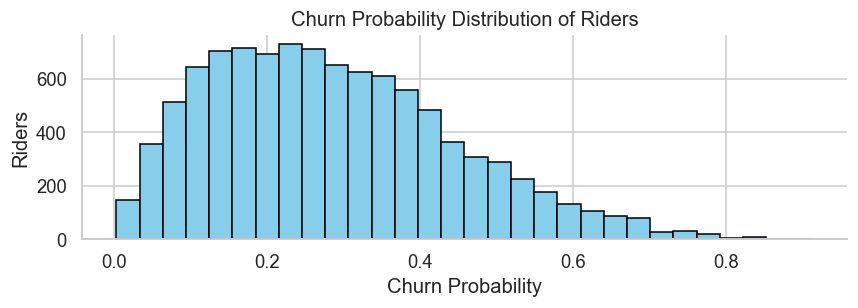

In [37]:
fig, ax = plt.subplots(figsize=(8,3))

ax.hist(
    riders["churn_prob"].dropna(), bins=30, color="skyblue", edgecolor="black")
ax.set(title="Churn Probability Distribution of Riders", xlabel="Churn Probability", ylabel="Riders")

plt.tight_layout()
plt.show()

## STEP 5 - Sign Up trends Overtime

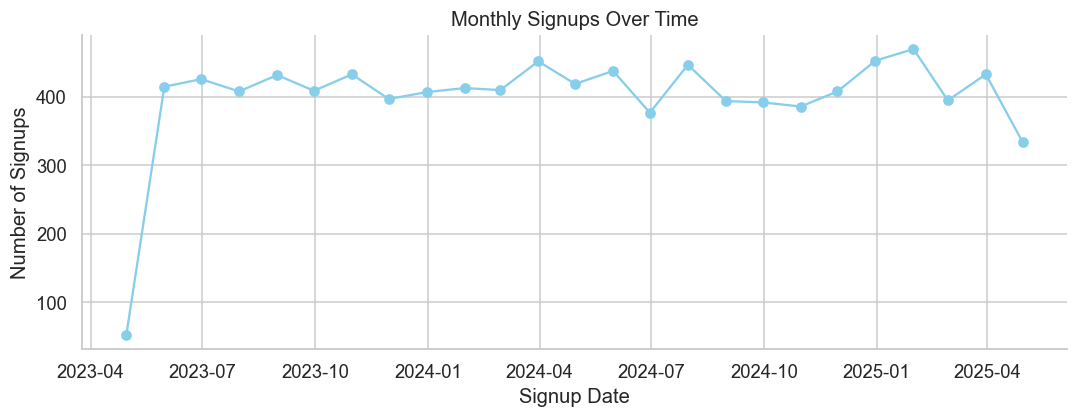

In [41]:
monthly = riders.set_index("signup_date").resample("M").size().reset_index(name="signups")

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(monthly["signup_date"], monthly["signups"], marker="o", color="skyblue")
ax.set(title="Monthly Signups Over Time", xlabel="Signup Date", ylabel="Number of Signups")
plt.tight_layout()
plt.show()